# M66 Baseline Simulation and AI Service Optimization

**Project:** Passenger Queue Dynamics and Waiting-Time Simulation for Selected M66 Bus Stops

This notebook builds the baseline discrete-event simulation, runs the required stochastic replications, and compares three AI optimization techniques for hourly M66 service allocation.

The simulation uses the cleaned 2025 MTA Bus Stop-Level Ridership data and the current MTA static GTFS schedule. The AI optimization changes the hourly number and spacing of candidate buses while keeping the simulation rules and passenger streams consistent.

Run this notebook from the first cell with a fresh kernel. Follow the notebook order in the root README, use the code folder as the working directory, and save the notebook with its outputs.


### Notebook Role

**Purpose:** Build and validate the Baseline discrete-event simulation, run the 30-replication Baseline experiment, screen GA/SA/PSO, and select GA for the succeeding optimization stage.

**Run order:** 2 of 4

**Main outputs:** Baseline replication and precision results, optimizer-screening evidence, selected Baseline GA plans, and Baseline comparison figures.

**Technical reference:** `../docs/TECHNICAL_DOCUMENTATION.md`


### Data Sources
MTA Bus Stop Level Ridership: Beginning 2024
https://data.ny.gov/d/fvdm-uavx

MTA Developer Resources / Static GTFS
https://www.mta.info/developers

GTFS Schedule Reference
https://gtfs.org/documentation/schedule/reference/

### Development And Documentation Note
AI-assisted suggestions were used as a starting point for some Python code.
The group reviewed the simulation rules, adapted the code to the M66 project,
ran the notebook using the actual project data, checked the outputs, and kept
the final code that matched the project design.

Official MTA, GTFS, pandas, NumPy, SciPy, Matplotlib, and Python documentation
was used to check the functions and procedures in this notebook.


In [1]:
#import the libraries used for data handling, simulation, statistics, and plots.
from pathlib import Path
import heapq
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t

## 1. Load and Prepare Passenger Demand

In [2]:
#define the main project directories and input file locations.
working_dir = Path.cwd()

project_candidates = [
    working_dir,
    working_dir.parent,
    working_dir / "MODESIM_Project",
]

project_dir = next(
    (
        path
        for path in project_candidates
        if (path / "code").exists() and (path / "data").exists()
    ),
    None,
)

if project_dir is None:
    raise FileNotFoundError(
        "Could not locate MODESIM_Project. "
        "Run the notebook from the repository root or MODESIM_Project/code."
    )

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
gtfs_dir = raw_dir / "gtfs_m"

figures_dir = project_dir / "output" / "figures"
tables_dir = project_dir / "output" / "tables"

clean_file = processed_dir / "MTA_M66_Selected_Stops_2025_CLEAN.csv"
raw_file = raw_dir / "MTA_M66_Eastbound_2025_RAW.csv"

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

#check that all required simulation input files are available before continuing.
required_inputs = [
    clean_file,
    raw_file,
    gtfs_dir / "trips.txt",
    gtfs_dir / "stop_times.txt",
    gtfs_dir / "feed_info.txt",
]

missing_inputs = [path for path in required_inputs if not path.exists()]

if missing_inputs:
    missing_list = "\n".join(f"- {path}" for path in missing_inputs)
    raise FileNotFoundError(
        "Required simulation input files are missing:\n"
        f"{missing_list}"
    )
#make local modules work from the repository root or the notebook folder
import sys
code_dir = str(project_dir / "code")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)
from m66_support import (
    PASSENGER_COLUMNS, allocate_initial_occupancy, finite_replications,
    paired_difference, validate_demand
)


In [3]:
#baseline simulation and optimizer-screening configuration.

bus_capacity = 60

morning_hours = [6, 7, 8, 9, 10]
evening_hours = [15, 16, 17, 18, 19]
study_hours = morning_hours + evening_hours

selected_stops = [6, 7, 8, 9, 10]

base_replications = 30
master_seed = 2026

#the ai screening uses the first 5 matched replications during search.
optimization_replications = list(range(1, 6))

#seeds and search budget used for the completed ga, sa, and pso screening.
optimizer_seeds = [101, 202, 303]
evaluation_budget = 10

In [4]:
#reference: pandas.read_csv()
#https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

#load the cleaned five-stop ridership dataset.
df = pd.read_csv(clean_file)

#convert date and hour into formats used by the simulation.
df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = pd.to_datetime(df["Hour"]).dt.hour

print("Cleaned rows:", len(df))
print("Study hours:", sorted(df["Hour"].unique()))
print("Selected stops:", sorted(df["Stop Sequence"].unique()))

df.head()

Cleaned rows: 12814
Study hours: [np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19)]
Selected stops: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,Date,Hour,Route ID,Direction,Stop ID,Stop Sequence,Boardings,Alightings,Trips,Stop Name,Period
0,2025-01-01,9,M66,E,403497,10,2,1,1,E 68 ST/LEXINGTON AV,Morning
1,2025-01-01,15,M66,E,403492,6,8,0,1,W 65 ST/CENTRAL PARK WEST,Evening
2,2025-01-01,15,M66,E,404994,8,0,4,1,MADISON AV/E 65 ST,Evening
3,2025-01-01,15,M66,E,403495,9,3,2,2,MADISON AV/E 67 ST,Evening
4,2025-01-01,15,M66,E,403497,10,0,1,1,E 68 ST/LEXINGTON AV,Evening


In [5]:
#reference: pandas dataframe.groupby()
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

#calculate the average mean boardings and alightings for each stop-hour.
demand_table = (
    df.groupby(["Stop Sequence", "Stop Name", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
    .sort_values(["Stop Sequence", "Hour"])
    .reset_index(drop=True)
)

#project deliverable 1 defines deterministic rounding for whole passengers:
#max(0, floor(p + 0.5)).
#
#reference: numpy floor()
#https://numpy.org/doc/stable/reference/generated/numpy.floor.html

baseline_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

baseline_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(baseline_demand["Boardings"] + 0.5)
).astype(int)

print("Passenger total per replication:", baseline_demand["Passenger Count"].sum())
baseline_demand.head(10)

Passenger total per replication: 776


,Stop Sequence,Stop Name,Hour,Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,8
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,25
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,40
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,24
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,19
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,34
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,28
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,31
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,22
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,11


In [6]:
#individual passenger arrival times are sampled within each hour because the
#mta ridership file contains hourly totals instead of passenger timestamps.
#
#kieu and cai (2018) discuss stochastic passenger-arrival modeling for public
#transport stops. for this project, the hourly passenger count stays fixed and
#only the within-hour arrival times change between replications.
#https://doi.org/10.1049/iet-its.2018.0085
#
#reference: numpy generator.uniform()
#https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html

def generate_baseline_passengers(seed, replication):
    #generate one reproducible baseline passenger stream for a replication.
    #use the supplied replication seed so passenger arrivals are reproducible.
    validate_demand(baseline_demand)
    rng = np.random.default_rng(seed)
    #collect one record for every generated virtual passenger.
    records = []

    for _, row in baseline_demand.iterrows():
        start_minute = int(row["Hour"]) * 60
        end_minute = start_minute + 60

        arrival_times = rng.uniform(
            start_minute,
            end_minute,
            int(row["Passenger Count"])
        )

        for arrival_time in sorted(arrival_times):
            records.append({
                "Stop Sequence": int(row["Stop Sequence"]),
                "Stop Name": row["Stop Name"],
                "Hour": int(row["Hour"]),
                "Period": "Morning" if row["Hour"] < 12 else "Evening",
                "Arrival Minutes": float(arrival_time)
            })

    passengers = pd.DataFrame(records, columns=PASSENGER_COLUMNS)

    passengers.insert(
        0,
        "Passenger ID",
        [
            f"R{replication:02d}_P{i:05d}"
            for i in range(1, len(passengers) + 1)
        ]
    )

    passengers["Replication"] = int(replication)
    passengers["Seed"] = int(seed)

    return passengers

## 2. Load and Prepare the Baseline GTFS Service

In [7]:
#load the current mta gtfs files.
trips = pd.read_csv(gtfs_dir / "trips.txt")
stop_times = pd.read_csv(gtfs_dir / "stop_times.txt")
feed_info = pd.read_csv(gtfs_dir / "feed_info.txt")

#keep the weekday eastbound m66 full-route pattern.
m66_trips = trips[
    (trips["route_id"] == "M66")
    & (trips["service_id"] == "MQ_C6-Weekday")
    & (trips["direction_id"] == 0)
    & (trips["shape_id"] == "M660030")
].copy()

print("Full-route weekday trips:", len(m66_trips))

feed_info[
    ["feed_publisher_name", "feed_start_date", "feed_end_date", "feed_version"]
].head()

Full-route weekday trips: 138


,feed_publisher_name,feed_start_date,feed_end_date,feed_version
0,MTA New York City Transit,20260627,20260905,gtfs_m_20260611T155328Z


In [8]:
#keep gtfs stop-time records for the five selected stops.
selected_stop_times = stop_times[
    stop_times["trip_id"].isin(m66_trips["trip_id"])
    & stop_times["stop_sequence"].between(6, 10)
].copy()

#use stop sequence 6 to assign each trip to a study hour.
first_stop_times = selected_stop_times[
    selected_stop_times["stop_sequence"] == 6
].copy()

first_stop_times["Hour"] = (
    first_stop_times["arrival_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

study_trip_ids = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
]["trip_id"]

study_stop_times = selected_stop_times[
    selected_stop_times["trip_id"].isin(study_trip_ids)
].copy()

#convert gtfs time text into minutes from midnight.
def time_to_minutes(time_text):
    #convert a gtfs hh:mm:ss time value to minutes after midnight.
    hours, minutes, seconds = map(int, time_text.split(":"))
    return (hours * 60) + minutes + (seconds / 60)

study_stop_times["arrival_minutes"] = (
    study_stop_times["arrival_time"].apply(time_to_minutes)
)

#count the baseline scheduled trips by hour.
trips_per_hour = (
    first_stop_times[
        first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
)

print("Study-period trips:", study_trip_ids.nunique())
print("Study-period stop events:", len(study_stop_times))
print("\nTrips per hour:")
print(trips_per_hour)

Study-period trips: 87
Study-period stop events: 435

Trips per hour:
Hour
6      5
7     12
8     12
9      8
10     6
15     8
16    12
17    11
18     8
19     5
dtype: int64


In [9]:
#create the baseline service-plan table.
baseline_service_plan = trips_per_hour.reset_index(name="Trips")

baseline_service_plan["Period"] = np.where(
    baseline_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

service_budget = (
    baseline_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

print("Morning service budget:", service_budget["Morning"])
print("Evening service budget:", service_budget["Evening"])

baseline_service_plan

Morning service budget: 43
Evening service budget: 44


,Hour,Trips,Period
0,6,5,Morning
1,7,12,Morning
2,8,12,Morning
3,9,8,Morning
4,10,6,Morning
5,15,8,Evening
6,16,12,Evening
7,17,11,Evening
8,18,8,Evening
9,19,5,Evening


## 3. Prepare Upstream Occupancy and Alighting Inputs

In [10]:
#load the raw eastbound m66 ridership file for upstream occupancy estimation.
raw_m66 = pd.read_csv(raw_file)

raw_m66["Date"] = pd.to_datetime(raw_m66["Date"])
raw_m66["Hour"] = pd.to_datetime(raw_m66["Hour"]).dt.hour

#identify the five physical upstream stops from the same full-route gtfs pattern.
upstream_gtfs_stops = (
    stop_times[
        stop_times["trip_id"].isin(m66_trips["trip_id"])
        & stop_times["stop_sequence"].between(1, 5)
    ][["stop_id", "stop_sequence"]]
    .drop_duplicates()
    .sort_values("stop_sequence")
)

upstream_stop_ids = (
    upstream_gtfs_stops["stop_id"]
    .astype(int)
    .tolist()
)

#keep weekday study-hour records from only those verified upstream stops.
upstream_df = raw_m66[
    (raw_m66["Date"].dt.dayofweek < 5)
    & (raw_m66["Stop ID"].isin(upstream_stop_ids))
    & (raw_m66["Hour"].isin(study_hours))
].copy()

#remove rows with passenger activity but zero observed trips.
upstream_clean = upstream_df[
    ~(
        (upstream_df["Trips"] == 0)
        & (
            (upstream_df["Boardings"] > 0)
            | (upstream_df["Alightings"] > 0)
        )
    )
].copy()

print("Verified upstream Stop IDs:", upstream_stop_ids)
print("Upstream rows before cleaning:", len(upstream_df))
print("Upstream rows after cleaning:", len(upstream_clean))

Verified upstream Stop IDs: [403487, 403488, 403489, 403491, 403573]
Upstream rows before cleaning: 10870
Upstream rows after cleaning: 10867


In [11]:
#calculate mean upstream boardings and alightings by physical stop and hour.
upstream_stop_hour = (
    upstream_clean
    .groupby(["Stop ID", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
)

#sum the stop-level means to estimate the average upstream passenger flow.
upstream_hourly_flow = (
    upstream_stop_hour
    .groupby("Hour")[["Boardings", "Alightings"]]
    .sum()
    .reset_index()
    .rename(
        columns={
            "Boardings": "Average Upstream Boardings",
            "Alightings": "Average Upstream Alightings"
        }
    )
)

upstream_hourly_flow["Upstream Net Flow"] = (
    upstream_hourly_flow["Average Upstream Boardings"]
    - upstream_hourly_flow["Average Upstream Alightings"]
)

upstream_hourly_flow["Scheduled Buses"] = (
    upstream_hourly_flow["Hour"].map(trips_per_hour)
)

upstream_hourly_flow["Upstream Passenger Target"] = np.floor(
    upstream_hourly_flow["Upstream Net Flow"].clip(lower=0) + 0.5
).astype(int)
upstream_hourly_flow["Initial Occupancy"] = (
    upstream_hourly_flow["Upstream Passenger Target"] / upstream_hourly_flow["Scheduled Buses"]
)

#keep the unrounded flow for all reference and candidate allocations
upstream_net_flow_by_hour = upstream_hourly_flow.set_index("Hour")["Upstream Net Flow"].to_dict()

upstream_hourly_flow[
    [
        "Hour",
        "Upstream Net Flow",
        "Scheduled Buses",
        "Upstream Passenger Target",
        "Initial Occupancy"
    ]
]

,Hour,Upstream Net Flow,Scheduled Buses,Upstream Passenger Target,Initial Occupancy
0,6,60.132476,5,60,12.000000
1,7,163.631926,12,164,13.666667
2,8,211.704836,12,212,17.666667
3,9,124.995854,8,125,15.625000
4,10,91.587024,6,92,15.333333
5,15,137.208668,8,137,17.125000
6,16,122.268987,12,122,10.166667
7,17,118.860856,11,119,10.818182
8,18,95.938313,8,96,12.000000
9,19,49.363709,5,49,9.800000


In [12]:
#allocate one rounded hourly target across the actual reference buses
trip_initial_occupancy = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()
trip_initial_occupancy["Period"] = np.where(
    trip_initial_occupancy["Hour"] < 12, "Morning", "Evening"
)
trip_initial_occupancy = allocate_initial_occupancy(
    trip_initial_occupancy, upstream_net_flow_by_hour, bus_capacity
)
trip_initial_occupancy.head()


,trip_id,Hour,Period,Initial Occupancy
61,MQ_C6-Weekday-036700_M66_501,6,Morning,12
75,MQ_C6-Weekday-037900_M66_504,6,Morning,12
89,MQ_C6-Weekday-039100_M66_502,6,Morning,12
103,MQ_C6-Weekday-040100_M66_505,6,Morning,12
117,MQ_C6-Weekday-040900_M66_503,6,Morning,12


In [13]:
#convert the average hourly alighting means into whole-number targets.
hourly_alighting_targets = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Alightings"]
].copy()

hourly_alighting_targets["Alighting Target"] = np.maximum(
    0,
    np.floor(hourly_alighting_targets["Alightings"] + 0.5)
).astype(int)

#build one record for every baseline bus-stop event.
bus_alighting_plan = study_stop_times[
    ["trip_id", "stop_sequence", "arrival_minutes"]
].copy()

bus_alighting_plan = bus_alighting_plan.merge(
    trip_initial_occupancy[["trip_id", "Hour", "Period"]],
    on="trip_id",
    how="left"
)

bus_alighting_plan = bus_alighting_plan.rename(
    columns={"stop_sequence": "Stop Sequence"}
)

bus_alighting_plan = bus_alighting_plan.merge(
    hourly_alighting_targets[
        ["Stop Sequence", "Hour", "Alighting Target"]
    ],
    on=["Stop Sequence", "Hour"],
    how="left"
)

bus_alighting_plan = bus_alighting_plan.sort_values(
    ["Stop Sequence", "Hour", "arrival_minutes"]
).reset_index(drop=True)

bus_alighting_plan["Assigned Alightings"] = 0

#use quotient and remainder so every stop-hour target is preserved.
for (stop, hour), group in bus_alighting_plan.groupby(
    ["Stop Sequence", "Hour"]
):
    target = int(group["Alighting Target"].iloc[0])
    bus_count = len(group)

    quotient = target // bus_count
    remainder = target % bus_count

    assignments = [quotient + 1] * remainder
    assignments += [quotient] * (bus_count - remainder)

    bus_alighting_plan.loc[
        group.index,
        "Assigned Alightings"
    ] = assignments

alighting_check = (
    bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(
        Target=("Alighting Target", "first"),
        Assigned=("Assigned Alightings", "sum")
    )
    .reset_index()
)

print(
    "All baseline alighting targets preserved:",
    (alighting_check["Target"] == alighting_check["Assigned"]).all()
)

All baseline alighting targets preserved: True


In [14]:
#create baseline lookup dictionaries used by the event handlers.
initial_occupancy_lookup = (
    trip_initial_occupancy
    .set_index("trip_id")["Initial Occupancy"]
    .to_dict()
)

alighting_lookup = (
    bus_alighting_plan
    .set_index(["trip_id", "Stop Sequence"])["Assigned Alightings"]
    .to_dict()
)

#create a trip-to-period lookup.
trip_period_lookup = (
    trip_initial_occupancy
    .set_index("trip_id")["Period"]
    .to_dict()
)

print("Initial occupancy values:", len(initial_occupancy_lookup))
print("Bus-stop alighting values:", len(alighting_lookup))

Initial occupancy values: 87
Bus-stop alighting values: 435


## 4. Discrete-Event Simulation Engine

In [15]:
#python heapq is used as the chronological event queue.
#https://docs.python.org/3/library/heapq.html
#
#if a bus and passenger have the exact same timestamp, the bus is processed
#first. the tuple priority uses bus=0 and passenger=1.

from m66_core import handle_passenger_arrival


from m66_core import handle_bus_arrival


In [16]:
def create_baseline_period_event_queues(passengers):
    #build chronological morning and evening event queues for the baseline passenger stream and gtfs service.
    #keep morning and evening event queues separate because the study periods are simulated independently.
    morning_events = []
    evening_events = []

    #add preserved passenger-arrival events.
    #add passenger arrivals with lower priority than buses at an exact time tie.
    for _, passenger in passengers.iterrows():
        event = (
            float(passenger["Arrival Minutes"]),
            1,
            "passenger_arrival",
            int(passenger["Stop Sequence"]),
            passenger["Passenger ID"]
        )

        if passenger["Period"] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    #add the fixed actual-gtfs bus events.
    for _, bus in study_stop_times.iterrows():
        event = (
            float(bus["arrival_minutes"]),
            0,
            "bus_arrival",
            int(bus["stop_sequence"]),
            bus["trip_id"]
        )

        if trip_period_lookup[bus["trip_id"]] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    return morning_events, evening_events

In [17]:
from m66_core import run_service_simulation as run_shared_simulation


def run_service_simulation(period, events, generated_passengers, replication, seed,
                           occupancy_lookup, service_alighting_lookup):
    #keep the four-result baseline interface while using the same event engine
    result = run_shared_simulation(period, events, generated_passengers, replication,
                                   seed, occupancy_lookup, service_alighting_lookup)
    return result[:4]


## 5. Run the Baseline Replications

In [18]:
#project deliverable 1 starts with 30 independent seed sets.
#numpy seedsequence.spawn() creates reproducible child random streams.
#https://numpy.org/doc/stable/reference/random/parallel.html

seed_sequence = np.random.SeedSequence(master_seed)
child_sequences = seed_sequence.spawn(base_replications)

replication_seeds = [
    int(child.generate_state(1)[0])
    for child in child_sequences
]

seed_table = pd.DataFrame({
    "Replication": range(1, base_replications + 1),
    "Seed": replication_seeds
})

seed_table.head(10)

,Replication,Seed
0,1,479243620
1,2,454024514
2,3,1818751028
3,4,2288458700
4,5,2115331525
5,6,2666256175
6,7,975381835
7,8,2535166222
8,9,1079577930
9,10,3715024065


In [19]:
#generate and preserve all 30 baseline passenger streams.
passenger_streams = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    passenger_streams.append(
        generate_baseline_passengers(
            seed=int(seed),
            replication=int(replication)
        )
    )

master_passenger_streams = pd.concat(
    passenger_streams,
    ignore_index=True
)

print("Replications saved:", master_passenger_streams["Replication"].nunique())
print("Passenger records saved:", len(master_passenger_streams))
print(
    "Passengers per replication:",
    master_passenger_streams.groupby("Replication").size().unique()
)

#store each replication once so candidate evaluations do not repeatedly
#filter the complete passenger table.
passengers_by_replication = {
    int(replication): group.copy()
    for replication, group in master_passenger_streams.groupby("Replication")
}

Replications saved: 30
Passenger records saved: 23280
Passengers per replication: [776]


In [20]:
#run the actual-gtfs baseline for all 30 passenger streams.
baseline_results = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    passengers = master_passenger_streams[
        master_passenger_streams["Replication"] == replication
    ].copy()

    morning_events, evening_events = create_baseline_period_event_queues(
        passengers
    )

    morning_passengers = int(
        (passengers["Period"] == "Morning").sum()
    )
    evening_passengers = int(
        (passengers["Period"] == "Evening").sum()
    )

    morning_result, _, _, _ = run_service_simulation(
        period="Morning",
        events=morning_events,
        generated_passengers=morning_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    evening_result, _, _, _ = run_service_simulation(
        period="Evening",
        events=evening_events,
        generated_passengers=evening_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    baseline_results.extend(
        [morning_result, evening_result]
    )

baseline_results_df = pd.DataFrame(baseline_results)

print("Baseline result rows:", len(baseline_results_df))
print(
    "All passenger conservation checks passed:",
    baseline_results_df["Passenger Conservation"].all()
)

baseline_results_df.head()

Baseline result rows: 60
All passenger conservation checks passed: True


,Replication,Seed,Period,Generated Passengers,Completed Passengers,Mean Completed Wait,Median Completed Wait,P95 Completed Wait,Maximum Completed Wait,Minimum Completed Wait,...,Peak Queue Stop,Peak Queue Time,Period-End Queue,Final Backlog,Mean Bus Occupancy,Maximum Bus Occupancy,Minimum Bus Occupancy,Passenger Conservation,Waiting Time Valid,Bus Occupancy Valid
0,1,479243620,Morning,500,497,3.528452,3.034578,8.760788,12.785716,0.039394,...,10,403.871403,5,3,15.693023,28,9,True,True,True
1,1,479243620,Evening,276,273,3.608862,3.200341,7.508045,21.203373,0.031487,...,10,921.909650,3,3,12.231818,24,2,True,True,True
2,2,454024514,Morning,500,500,3.555722,3.047459,9.438976,13.712288,0.008342,...,10,468.978623,3,0,15.762791,28,8,True,True,True
3,2,454024514,Evening,276,274,3.629559,3.486543,7.433749,16.877333,0.023747,...,10,919.849591,2,2,12.245455,24,1,True,True,True
4,3,1818751028,Morning,500,499,3.747295,3.242815,8.535083,17.113319,0.004535,...,10,468.613961,2,1,15.739535,29,9,True,True,True


In [21]:
#law (2024) supports confidence-interval analysis across independent simulation
#replications. project deliverable 1 uses a 95% confidence interval and starts
#with 30 replications.
#
#reference: scipy student t distribution
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

precision_records = []

for period in ["Morning", "Evening"]:
    period_results = baseline_results_df[
        baseline_results_df["Period"] == period
    ]

    for metric in ["Mean Completed Wait", "Peak Queue"]:
        values = pd.Series(finite_replications(period_results[metric]))

        n = len(values)
        mean_value = values.mean()
        std_value = values.std(ddof=1)
        standard_error = std_value / np.sqrt(n)

        t_critical = t.ppf(0.975, df=n - 1)
        half_width = t_critical * standard_error

        lower_ci = mean_value - half_width
        upper_ci = mean_value + half_width

        if mean_value < 10:
            required_half_width = 1.0
        else:
            required_half_width = 0.10 * mean_value

        precision_records.append({
            "Period": period,
            "Metric": metric,
            "Replications": n,
            "Mean": mean_value,
            "Standard Deviation": std_value,
            "CI Lower": lower_ci,
            "CI Upper": upper_ci,
            "Half-Width": half_width,
            "Required Half-Width": required_half_width,
            "Precision Passed": half_width <= required_half_width
        })

baseline_precision = pd.DataFrame(precision_records)

baseline_precision.round(3)

,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,Morning,Mean Completed Wait,30,3.657,0.110,3.616,3.698,0.041,1.000,True
1,Morning,Peak Queue,30,17.267,1.999,16.520,18.013,0.746,1.727,True
2,Evening,Mean Completed Wait,30,3.651,0.164,3.590,3.712,0.061,1.000,True
3,Evening,Peak Queue,30,9.867,1.570,9.280,10.453,0.586,1.000,True


In [22]:
#save the completed baseline inputs and outputs.
master_passenger_streams.to_csv(
    processed_dir / "M66_Master_Passenger_Streams_30_Replications.csv",
    index=False
)

seed_table.to_csv(
    processed_dir / "M66_Replication_Seeds.csv",
    index=False
)

baseline_results_df.to_csv(
    processed_dir / "M66_Baseline_30_Replications.csv",
    index=False
)

baseline_precision.to_csv(
    processed_dir / "M66_Baseline_Precision_Check.csv",
    index=False
)

print(
    "30 replications sufficient:",
    baseline_precision["Precision Passed"].all()
)

30 replications sufficient: True


## 6. Build Candidate Service Plans for AI Evaluation

In [23]:
#candidate service plans keep the same total number of buses as the baseline
#during the ai technique comparison. the optimizer changes the hourly allocation.
#
#oliveira et al. (2024) include minimum and maximum departure frequencies in a
#bus frequency-setting model.
#https://doi.org/10.1016/j.asoc.2024.111578

min_hourly_trips = int(baseline_service_plan["Trips"].min())
max_hourly_trips = int(baseline_service_plan["Trips"].max())

baseline_plan_lookup = {
    period: tuple(
        baseline_service_plan[
            baseline_service_plan["Period"] == period
        ]["Trips"].astype(int).tolist()
    )
    for period in ["Morning", "Evening"]
}

print("Minimum trips per hour:", min_hourly_trips)
print("Maximum trips per hour:", max_hourly_trips)
print("Morning baseline plan:", baseline_plan_lookup["Morning"])
print("Evening baseline plan:", baseline_plan_lookup["Evening"])

Minimum trips per hour: 5
Maximum trips per hour: 12
Morning baseline plan: (5, 12, 12, 8, 6)
Evening baseline plan: (8, 12, 11, 8, 5)


In [24]:
#use the gtfs schedule to measure the typical travel time from stop 6 to each
#downstream stop during each study hour.
trip_times = study_stop_times[
    ["trip_id", "stop_sequence", "arrival_minutes"]
].merge(
    trip_initial_occupancy[["trip_id", "Hour"]],
    on="trip_id",
    how="left"
)

stop6_times = (
    trip_times[
        trip_times["stop_sequence"] == 6
    ][["trip_id", "arrival_minutes"]]
    .rename(columns={"arrival_minutes": "stop6_arrival"})
)

trip_times = trip_times.merge(
    stop6_times,
    on="trip_id",
    how="left"
)

trip_times["Travel Offset"] = (
    trip_times["arrival_minutes"]
    - trip_times["stop6_arrival"]
)

hourly_travel_offsets = (
    trip_times
    .groupby(["Hour", "stop_sequence"])["Travel Offset"]
    .median()
    .reset_index()
    .rename(
        columns={
            "stop_sequence": "Stop Sequence",
            "Travel Offset": "Median Offset Minutes"
        }
    )
)

travel_offset_lookup = (
    hourly_travel_offsets
    .set_index(["Hour", "Stop Sequence"])["Median Offset Minutes"]
    .to_dict()
)

print("Hour-stop travel offsets:", len(travel_offset_lookup))
hourly_travel_offsets.head(10)

Hour-stop travel offsets: 50


,Hour,Stop Sequence,Median Offset Minutes
0,6,6,0.000000
1,6,7,3.516667
2,6,8,4.100000
3,6,9,5.466667
4,6,10,9.100000
5,7,6,0.000000
6,7,7,4.933333
7,7,8,5.741667
8,7,9,7.375000
9,7,10,11.741667


In [25]:
#gkiotsalitis (2020) discusses headway-based bus scheduling and passenger
#waiting time. candidate buses are evenly spaced inside each hour so a service
#plan can be converted into exact event times in a clear and repeatable way.
#https://doi.org/10.1049/iet-its.2019.0725
#
#the actual gtfs baseline still uses the exact published gtfs times.

def build_candidate_stop6_schedule(period, trip_counts):
    #create an evenly spaced candidate stop 6 schedule from a five-hour service-allocation plan.
    #select the five study hours for the requested morning or evening optimization period.
    hours = (
    morning_hours
    if period == "Morning"
    else evening_hours
)

    #build synthetic stop 6 bus arrivals from the candidate hourly trip counts.
    records = []

    #place buses at the midpoints of equal within-hour headway intervals.
    for hour, count in zip(hours, trip_counts):
        count = int(count)

        if count < 1:
            raise ValueError(
                "Each study hour must contain at least one bus."
            )

        headway = 60 / count

        #place each bus at the midpoint of an equal headway interval.
        within_hour_times = (
            np.arange(count) + 0.5
        ) * headway

        for trip_number, minute_offset in enumerate(
            within_hour_times,
            start=1
        ):
            records.append({
                "trip_id": f"CAND_{period}_{hour:02d}_{trip_number:02d}",
                "Hour": hour,
                "Period": period,
                "Stop 6 Arrival": hour * 60 + minute_offset,
                "Hourly Trips": count,
                "Headway Minutes": headway
            })

    return pd.DataFrame(records)


def expand_candidate_stop_times(candidate_schedule):
    #expand candidate stop 6 arrivals to all modeled stops using hour-specific gtfs median offsets.
    #expand each synthetic stop 6 arrival into one arrival event at every modeled stop.
    records = []

    #apply the hour-specific median gtfs downstream offset for each stop.
    for _, trip in candidate_schedule.iterrows():
        hour = int(trip["Hour"])

        for stop in selected_stops:
            records.append({
                "trip_id": trip["trip_id"],
                "Hour": hour,
                "Period": trip["Period"],
                "stop_sequence": stop,
                "arrival_minutes": (
                    float(trip["Stop 6 Arrival"])
                    + float(travel_offset_lookup[(hour, stop)])
                )
            })

    return pd.DataFrame(records)

In [26]:
def create_candidate_initial_occupancy(candidate_schedule):
    #a new bus count shares the same hourly passenger target
    flow = upstream_hourly_flow.set_index("Hour")["Upstream Net Flow"].to_dict()
    return allocate_initial_occupancy(candidate_schedule, flow, bus_capacity)


def create_candidate_alighting_plan(candidate_stop_times):
    #redistribute unchanged stop-hour alighting targets across the candidate buses while preserving each target.
    #attach the unchanged stop-hour alighting targets to the candidate service events.
    plan = candidate_stop_times.merge(
        hourly_alighting_targets[
            ["Stop Sequence", "Hour", "Alighting Target"]
        ],
        left_on=["stop_sequence", "Hour"],
        right_on=["Stop Sequence", "Hour"],
        how="left"
    )

    plan = plan.sort_values(
        ["stop_sequence", "Hour", "arrival_minutes"]
    ).reset_index(drop=True)

    #distribute the remainder while preserving the exact whole-number alighting target.
    plan["Assigned Alightings"] = 0

    for (stop, hour), group in plan.groupby(
        ["stop_sequence", "Hour"]
    ):
        target = int(group["Alighting Target"].iloc[0])
        bus_count = len(group)

        quotient = target // bus_count
        remainder = target % bus_count

        assignments = [quotient + 1] * remainder
        assignments += [quotient] * (bus_count - remainder)

        plan.loc[
            group.index,
            "Assigned Alightings"
        ] = assignments

    return plan

In [27]:
def create_candidate_event_queue(
    passengers,
    candidate_stop_times,
    period
):
    #build the chronological event queue for one candidate service plan and study period.
    #collect passenger and candidate-bus events in one chronological priority queue.
    events = []

    period_passengers = passengers[
        passengers["Period"] == period
    ]

    #passenger events use priority 1 so an exact-time bus arrival is processed first.
    for _, passenger in period_passengers.iterrows():
        heapq.heappush(
            events,
            (
                float(passenger["Arrival Minutes"]),
                1,
                "passenger_arrival",
                int(passenger["Stop Sequence"]),
                passenger["Passenger ID"]
            )
        )

    #candidate bus events use priority 0 and carry trip and stop information.
    for _, bus in candidate_stop_times.iterrows():
        heapq.heappush(
            events,
            (
                float(bus["arrival_minutes"]),
                0,
                "bus_arrival",
                int(bus["stop_sequence"]),
                bus["trip_id"]
            )
        )

    return events


def is_valid_service_plan(period, trip_counts):
    #check a five-hour service plan against the hourly bounds and fixed period budget.
    if period not in service_budget:
        return False

    try:
        raw_values = list(trip_counts)
    except TypeError:
        return False

    if len(raw_values) != 5:
        return False

    normalized = []

    for value in raw_values:
        if isinstance(value, (bool, np.bool_)):
            return False

        if not isinstance(
            value,
            (int, float, np.integer, np.floating)
        ):
            return False

        numeric_value = float(value)

        if (
            not np.isfinite(numeric_value)
            or not numeric_value.is_integer()
        ):
            return False

        normalized.append(
            int(numeric_value)
        )

    if any(
        count < min_hourly_trips
        or count > max_hourly_trips
        for count in normalized
    ):
        return False

    if sum(normalized) != int(
        service_budget[period]
    ):
        return False

    return True


In [28]:
def evaluate_candidate_replication(
    period,
    trip_counts,
    passengers,
    replication,
    seed
):
    #evaluate one candidate service plan on one matched passenger-demand replication.
    #normalize the service plan before constructing any candidate service inputs.
    #validate the raw service plan before any integer conversion.
    if not is_valid_service_plan(
        period,
        trip_counts
    ):
        raise ValueError(
            "Candidate service plan must contain five finite integer "
            "trip counts within the fixed Baseline constraints."
        )

    trip_counts = [
        int(value)
        for value in trip_counts
    ]

    candidate_schedule = build_candidate_stop6_schedule(
        period,
        trip_counts
    )

    candidate_stop_times = expand_candidate_stop_times(
        candidate_schedule
    )

    candidate_occupancy = create_candidate_initial_occupancy(
        candidate_schedule
    )

    candidate_alighting = create_candidate_alighting_plan(
        candidate_stop_times
    )

    occupancy_lookup = (
        candidate_occupancy
        .set_index("trip_id")["Initial Occupancy"]
        .to_dict()
    )

    candidate_alighting_lookup = (
        candidate_alighting
        .set_index(
            ["trip_id", "stop_sequence"]
        )["Assigned Alightings"]
        .to_dict()
    )

    candidate_events = create_candidate_event_queue(
        passengers,
        candidate_stop_times,
        period
    )

    generated_passengers = int(
        (passengers["Period"] == period).sum()
    )

    result, _, _, _ = run_service_simulation(
        period=period,
        events=candidate_events,
        generated_passengers=generated_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=occupancy_lookup,
        service_alighting_lookup=candidate_alighting_lookup
    )

    result["Service Plan"] = tuple(trip_counts)

    return result


def evaluate_candidate_replications(
    period,
    trip_counts,
    replication_ids
):
    #evaluate one candidate service plan across a specified set of matched replications.
    results = []

    seed_lookup = (
        seed_table
        .set_index("Replication")["Seed"]
        .to_dict()
    )

    #reuse the recorded seed and passenger stream for each matched replication.
    for replication in replication_ids:
        seed = int(seed_lookup[int(replication)])
        passengers = passengers_by_replication[int(replication)]

        results.append(
            evaluate_candidate_replication(
                period=period,
                trip_counts=trip_counts,
                passengers=passengers,
                replication=int(replication),
                seed=seed
            )
        )

    return pd.DataFrame(results)


def evaluate_candidate_30_replications(period, trip_counts):
    #evaluate one candidate service plan across the complete 30-replication validation set.
    return evaluate_candidate_replications(
        period=period,
        trip_counts=trip_counts,
        replication_ids=range(1, base_replications + 1)
    )

## 7. Define the AI Optimization Objective

In [29]:
#oliveira et al. (2024) use passenger waiting time as an objective in bus
#frequency setting. for this project, lower mean completed waiting time is the
#main objective.
#https://doi.org/10.1016/j.asoc.2024.111578
#
#final backlog is a safeguard. a plan is feasible only when its mean backlog
#does not exceed the actual-gtfs baseline for the same period.

optimization_reference = (
    baseline_results_df
    .groupby("Period")
    .agg(
        Baseline_Mean_Wait=("Mean Completed Wait", "mean"),
        Baseline_Mean_Backlog=("Final Backlog", "mean"),
        Baseline_Mean_Peak_Queue=("Peak Queue", "mean")
    )
    .reset_index()
)

#use the first 5 matched replications while the optimizers search.
#the best plan from every optimizer run is later checked again using all 30
#replications before the techniques are compared.

optimization_reference_search = (
    baseline_results_df[
        baseline_results_df["Replication"].isin(optimization_replications)
    ]
    .groupby("Period")
    .agg(
        Baseline_Mean_Wait=("Mean Completed Wait", "mean"),
        Baseline_Mean_Backlog=("Final Backlog", "mean"),
        Baseline_Mean_Peak_Queue=("Peak Queue", "mean")
    )
    .reset_index()
)

optimization_reference.round(3)

,Period,Baseline_Mean_Wait,Baseline_Mean_Backlog,Baseline_Mean_Peak_Queue
0,Evening,3.651,3.233,9.867
1,Morning,3.657,2.167,17.267


In [30]:
#cache the screening fitness values so repeated service plans do not rerun the
#same 5-replication search evaluation. the final algorithm comparison still
#validates each run's best plan using all 30 replications.
fitness_cache = {}

def evaluate_service_plan_fitness(period, trip_counts):
    #return the mean completed wait for a feasible candidate plan and reject plans that violate the backlog safeguard.
    #use an immutable service-plan key so repeated candidate evaluations can be cached.
    #reject malformed plans before integer conversion and caching.
    if not is_valid_service_plan(
        period,
        trip_counts
    ):
        raise ValueError(
            "Fitness evaluation requires a valid finite integer service plan."
        )

    plan = tuple(int(x) for x in trip_counts)
    key = (period, plan)

    if key not in fitness_cache:
        results = evaluate_candidate_replications(
            period=period,
            trip_counts=list(plan),
            replication_ids=optimization_replications
        )

        mean_wait = results["Mean Completed Wait"].mean()
        mean_backlog = results["Final Backlog"].mean()
        mean_peak_queue = results["Peak Queue"].mean()
        mean_p95_wait = results["P95 Completed Wait"].mean()

        reference = optimization_reference_search[
            optimization_reference_search["Period"] == period
        ].iloc[0]

        feasible = (
            mean_backlog
            <= reference["Baseline_Mean_Backlog"]
        )
        #undefined completed-wait fitness is never considered feasible.
        if not np.isfinite(mean_wait):
            feasible = False

        fitness_cache[key] = {
            "Period": period,
            "Service Plan": plan,
            "Fitness": float(mean_wait) if feasible else np.inf,
            "Mean Wait": float(mean_wait),
            "Mean Backlog": float(mean_backlog),
            "Mean Peak Queue": float(mean_peak_queue),
            "Mean P95 Wait": float(mean_p95_wait),
            "Feasible": bool(feasible)
        }

    return fitness_cache[key]

## 8. Experimental AI Techniques

Three metaheuristic techniques are compared using the same service-plan limits, passenger streams, simulation model, and fitness function.

- **Genetic Algorithm (GA):** Oliveira et al. (2024) used a biased random-key genetic algorithm for bus frequency setting and passenger waiting-time optimization. https://doi.org/10.1016/j.asoc.2024.111578
- **Simulated Annealing (SA):** Ahern, Paz, and Corry (2022) used multi-objective simulated annealing for integrated bus route design and service frequency setting. https://doi.org/10.1016/j.trb.2021.10.007
- **Particle Swarm Optimization (PSO):** Han, Ma, and Guo (2022) used PSO for bus timetable and headway optimization. https://doi.org/10.1061/9780784484265.049

Each optimizer run searches with the same 10-plan evaluation budget using the first 5 matched simulation replications. The best plan from every run is then validated using all 30 replications. This two-stage setup keeps the search time manageable while keeping the final technique comparison based on the full simulation experiment.

Three optimizer seeds are used for each technique and period to check whether the technique gives similar results across repeated optimizer runs.

In [31]:
#helper functions shared by all optimization techniques.

def random_valid_plan(period, rng):
    #generate a random five-hour service plan that satisfies the fixed budget and hourly bounds.
    #start from the scenario-specific fixed morning or evening trip budget.
    budget = int(service_budget[period])

    while True:
        plan = rng.integers(
            min_hourly_trips,
            max_hourly_trips + 1,
            size=5
        )

        if int(plan.sum()) == budget:
            return tuple(int(x) for x in plan)


def repair_service_plan(period, values, rng):
    #repair a proposed service allocation so it satisfies the hourly bounds and fixed period budget.
    #convert the proposed values to integer hourly trip counts before repair.
    plan = np.rint(
        np.array(values, dtype=float)
    ).astype(int)

    #enforce the hourly bounds before correcting the total service budget.
    plan = np.clip(
        plan,
        min_hourly_trips,
        max_hourly_trips
    )

    budget = int(service_budget[period])

    while plan.sum() < budget:
        choices = np.where(
            plan < max_hourly_trips
        )[0]
        plan[int(rng.choice(choices))] += 1

    while plan.sum() > budget:
        choices = np.where(
            plan > min_hourly_trips
        )[0]
        plan[int(rng.choice(choices))] -= 1

    return tuple(int(x) for x in plan)


def neighboring_service_plan(period, plan, rng):
    #create a nearby feasible service plan by moving one trip between study hours.
    #work on a copy so the original candidate plan is not modified in place.
    plan = np.array(plan, dtype=int)

    donors = np.where(
        plan > min_hourly_trips
    )[0]

    receivers = np.where(
        plan < max_hourly_trips
    )[0]

    for _ in range(30):
        donor = int(rng.choice(donors))
        receiver = int(rng.choice(receivers))

        if donor != receiver:
            plan[donor] -= 1
            plan[receiver] += 1
            return tuple(int(x) for x in plan)

    return tuple(int(x) for x in plan)


def get_run_fitness(period, plan, seen_plans):
    #evaluate a service plan once per optimizer run and reuse its cached fitness when seen again.
    plan = tuple(int(x) for x in plan)

    result = evaluate_service_plan_fitness(
        period,
        plan
    )

    seen_plans.add(plan)

    return result

In [32]:
def run_genetic_algorithm(
    period,
    optimizer_seed,
    evaluation_budget=30,
    population_size=6
):
    #run the genetic algorithm for one period and optimizer seed under the fixed unique-plan evaluation budget.
    #use a dedicated optimizer seed so the ga search is reproducible.
    rng = np.random.default_rng(optimizer_seed)

    #seed the initial population with feasible service plans only.
    population = [baseline_plan_lookup[period]]

    while len(population) < population_size:
        plan = random_valid_plan(period, rng)
        if plan not in population:
            population.append(plan)

    seen_plans = set()
    best_result = None
    history = []

    #continue until 30 unique service plans have been evaluated.
    #continue until the agreed number of unique candidate plans has been evaluated.
    while len(seen_plans) < evaluation_budget:
        #score each unseen feasible candidate using the fixed search-replication set.
        scored = []

        for plan in population:
            if plan not in seen_plans and len(seen_plans) >= evaluation_budget:
                break

            result = get_run_fitness(
                period,
                plan,
                seen_plans
            )

            scored.append(
                (result["Fitness"], plan, result)
            )

            if (
                best_result is None
                or result["Fitness"] < best_result["Fitness"]
            ):
                best_result = result

            if len(seen_plans) >= evaluation_budget:
                break

        history.append(
            {
                "Technique": "GA",
                "Period": period,
                "Optimizer Seed": optimizer_seed,
                "Unique Plans Evaluated": len(seen_plans),
                "Best Fitness": best_result["Fitness"]
            }
        )

        if len(seen_plans) >= evaluation_budget:
            break

        scored = sorted(
            scored,
            key=lambda item: item[0]
        )

        #preserve the best current plans before generating the next population.
        elites = [
            scored[0][1],
            scored[min(1, len(scored) - 1)][1]
        ]

        #select parents by tournament so better plans are favored while retaining search diversity.
        def tournament_select():
            #select one ga parent by comparing a random subset of the current scored population.
            indexes = rng.choice(
                len(scored),
                size=min(3, len(scored)),
                replace=False
            )

            return min(
                [scored[int(i)] for i in indexes],
                key=lambda item: item[0]
            )[1]

        next_population = elites.copy()

        while len(next_population) < population_size:
            parent1 = np.array(tournament_select())
            parent2 = np.array(tournament_select())

            mask = rng.random(5) < 0.5
            child = np.where(
                mask,
                parent1,
                parent2
            )

            child = repair_service_plan(
                period,
                child,
                rng
            )

            if rng.random() < 0.5:
                child = neighboring_service_plan(
                    period,
                    child,
                    rng
                )

            next_population.append(child)

        population = next_population

    return best_result, pd.DataFrame(history)

In [33]:
def run_simulated_annealing(
    period,
    optimizer_seed,
    evaluation_budget=30,
    initial_temperature=0.20,
    cooling_rate=0.93
):
    #run simulated annealing for one period and optimizer seed under the fixed unique-plan evaluation budget.
    #use the optimizer seed to keep the simulated annealing screening run reproducible.
    rng = np.random.default_rng(optimizer_seed)

    #start from one feasible service allocation before exploring neighboring plans.
    current_plan = baseline_plan_lookup[period]
    seen_plans = set()

    current_result = get_run_fitness(
        period,
        current_plan,
        seen_plans
    )

    best_result = current_result
    temperature = initial_temperature
    history = []
    attempts = 0

    while (
        len(seen_plans) < evaluation_budget
        and attempts < 300
    ):
        attempts += 1

        candidate_plan = neighboring_service_plan(
            period,
            current_plan,
            rng
        )

        candidate_result = get_run_fitness(
            period,
            candidate_plan,
            seen_plans
        )

        current_fitness = current_result["Fitness"]
        candidate_fitness = candidate_result["Fitness"]

        accept = False

        if candidate_fitness < current_fitness:
            accept = True
        elif np.isfinite(candidate_fitness) and np.isfinite(current_fitness):
            probability = math.exp(
                -(candidate_fitness - current_fitness)
                / max(temperature, 1e-9)
            )
            accept = rng.random() < probability
        elif np.isfinite(candidate_fitness):
            accept = True

        if accept:
            current_plan = candidate_plan
            current_result = candidate_result

        if candidate_fitness < best_result["Fitness"]:
            best_result = candidate_result

        history.append({
            "Technique": "SA",
            "Period": period,
            "Optimizer Seed": optimizer_seed,
            "Unique Plans Evaluated": len(seen_plans),
            "Best Fitness": best_result["Fitness"]
        })

        temperature *= cooling_rate

    return best_result, pd.DataFrame(history)

In [34]:
def run_particle_swarm(
    period,
    optimizer_seed,
    evaluation_budget=30,
    swarm_size=6,
    inertia=0.70,
    cognitive=1.40,
    social=1.40
):
    #run particle swarm optimization for one period and optimizer seed under the fixed unique-plan evaluation budget.
    #use the optimizer seed to keep the particle swarm screening run reproducible.
    rng = np.random.default_rng(optimizer_seed)

    positions = [
        np.array(
            baseline_plan_lookup[period],
            dtype=float
        )
    ]

    while len(positions) < swarm_size:
        positions.append(
            np.array(
                random_valid_plan(period, rng),
                dtype=float
            )
        )

    velocities = [
        rng.uniform(-1, 1, size=5)
        for _ in range(swarm_size)
    ]

    personal_best = [None] * swarm_size
    personal_best_fitness = [np.inf] * swarm_size

    global_best = None
    global_best_result = None
    seen_plans = set()
    history = []
    attempts = 0

    while (
        len(seen_plans) < evaluation_budget
        and attempts < 300
    ):
        attempts += 1

        for i in range(swarm_size):
            plan = repair_service_plan(
                period,
                positions[i],
                rng
            )

            result = get_run_fitness(
                period,
                plan,
                seen_plans
            )

            fitness = result["Fitness"]

            if fitness < personal_best_fitness[i]:
                personal_best[i] = np.array(
                    plan,
                    dtype=float
                )
                personal_best_fitness[i] = fitness

            if (
                global_best_result is None
                or fitness < global_best_result["Fitness"]
            ):
                global_best = np.array(
                    plan,
                    dtype=float
                )
                global_best_result = result

            if len(seen_plans) >= evaluation_budget:
                break

        history.append({
            "Technique": "PSO",
            "Period": period,
            "Optimizer Seed": optimizer_seed,
            "Unique Plans Evaluated": len(seen_plans),
            "Best Fitness": global_best_result["Fitness"]
        })

        if len(seen_plans) >= evaluation_budget:
            break

        for i in range(swarm_size):
            if personal_best[i] is None:
                continue

            r1 = rng.random(5)
            r2 = rng.random(5)

            velocities[i] = (
                inertia * velocities[i]
                + cognitive * r1
                * (personal_best[i] - positions[i])
                + social * r2
                * (global_best - positions[i])
            )

            positions[i] = (
                positions[i]
                + velocities[i]
            )

            positions[i] = np.array(
                repair_service_plan(
                    period,
                    positions[i],
                    rng
                ),
                dtype=float
            )

    return global_best_result, pd.DataFrame(history)

In [35]:
#run the controlled ai technique comparison.
optimizer_run_records = []
convergence_records = []

optimizer_functions = {
    "GA": run_genetic_algorithm,
    "SA": run_simulated_annealing,
    "PSO": run_particle_swarm
}

for period in ["Morning", "Evening"]:
    for technique, function in optimizer_functions.items():
        for optimizer_seed in optimizer_seeds:
            search_best, history = function(
                period=period,
                optimizer_seed=optimizer_seed,
                evaluation_budget=evaluation_budget
            )

            #validate this run's best plan using all 30 simulation replications.
            validated_results = evaluate_candidate_30_replications(
                period=period,
                trip_counts=list(search_best["Service Plan"])
            )

            optimizer_run_records.append({
                "Period": period,
                "Technique": technique,
                "Optimizer Seed": optimizer_seed,
                "Evaluation Budget": evaluation_budget,
                "Search Best Fitness": search_best["Fitness"],
                "Best Service Plan": search_best["Service Plan"],
                "Validated Mean Wait": validated_results["Mean Completed Wait"].mean(),
                "Validated Mean Backlog": validated_results["Final Backlog"].mean(),
                "Validated Mean Peak Queue": validated_results["Peak Queue"].mean(),
                "Validated Mean P95 Wait": validated_results["P95 Completed Wait"].mean(),
                "Passenger Conservation": validated_results["Passenger Conservation"].all()
            })

            convergence_records.append(history)

optimizer_runs_df = pd.DataFrame(
    optimizer_run_records
)

optimizer_convergence_df = pd.concat(
    convergence_records,
    ignore_index=True
)

optimizer_runs_df

,Period,Technique,Optimizer Seed,Evaluation Budget,Search Best Fitness,Best Service Plan,Validated Mean Wait,Validated Mean Backlog,Validated Mean Peak Queue,Validated Mean P95 Wait,Passenger Conservation
0,Morning,GA,101,10,3.461648,"(8, 12, 10, 8, 5)",3.490233,2.100000,16.300000,7.558990,True
1,Morning,GA,202,10,3.503185,"(6, 10, 12, 8, 7)",3.514901,1.433333,17.733333,7.861143,True
2,Morning,GA,303,10,3.435064,"(8, 9, 11, 9, 6)",3.488068,1.833333,17.500000,7.146191,True
3,Morning,SA,101,10,3.523288,"(6, 11, 11, 7, 8)",3.546933,1.133333,17.466667,7.961091,True
4,Morning,SA,202,10,3.524859,"(5, 12, 12, 8, 6)",3.556695,1.833333,17.900000,9.097175,True
5,Morning,SA,303,10,3.416848,"(7, 12, 11, 7, 6)",3.469823,1.833333,16.366667,7.927951,True
6,Morning,PSO,101,10,3.495882,"(7, 11, 10, 7, 8)",3.539774,1.133333,17.033333,7.454737,True
7,Morning,PSO,202,10,3.416848,"(7, 12, 11, 7, 6)",3.469823,1.833333,16.366667,7.927951,True
8,Morning,PSO,303,10,3.448799,"(9, 9, 12, 7, 6)",3.477138,1.833333,16.966667,7.599172,True
9,Evening,GA,101,10,3.475658,"(11, 7, 9, 10, 7)",3.532199,0.966667,8.633333,7.473238,True


In [36]:
#summarize the 30-replication validation result from the three optimizer runs.
optimizer_summary = (
    optimizer_runs_df
    .groupby(["Period", "Technique"])
    .agg(
        Mean_Best_Wait=("Validated Mean Wait", "mean"),
        Std_Best_Wait=("Validated Mean Wait", "std"),
        Best_Wait=("Validated Mean Wait", "min"),
        Mean_Backlog=("Validated Mean Backlog", "mean"),
        Mean_Peak_Queue=("Validated Mean Peak Queue", "mean"),
        Mean_P95_Wait=("Validated Mean P95 Wait", "mean")
    )
    .reset_index()
)

optimizer_summary.round(4)

,Period,Technique,Mean_Best_Wait,Std_Best_Wait,Best_Wait,Mean_Backlog,Mean_Peak_Queue,Mean_P95_Wait
0,Evening,GA,3.5529,0.0223,3.5322,1.0222,8.6000,7.6446
1,Evening,PSO,3.5861,0.0358,3.5523,1.0333,8.7000,7.6394
2,Evening,SA,3.5820,0.0295,3.5582,0.9889,8.4889,8.0250
3,Morning,GA,3.4977,0.0149,3.4881,1.7889,17.1778,7.5221
4,Morning,PSO,3.4956,0.0384,3.4698,1.6000,16.7889,7.6606
5,Morning,SA,3.5245,0.0476,3.4698,1.6000,17.2444,8.3287


In [37]:
#select one final ai technique for the project.
#the first criterion is the lowest mean best waiting time across morning and
#evening. lower average run-to-run standard deviation is used as a tie-breaker.

technique_selection = (
    optimizer_summary
    .groupby("Technique")
    .agg(
        Average_Mean_Best_Wait=("Mean_Best_Wait", "mean"),
        Average_Run_SD=("Std_Best_Wait", "mean")
    )
    .reset_index()
    .sort_values(
        ["Average_Mean_Best_Wait", "Average_Run_SD"]
    )
    .reset_index(drop=True)
)

selected_technique = technique_selection.iloc[0]["Technique"]

print("Selected AI technique:", selected_technique)
technique_selection.round(4)

Selected AI technique: GA


,Technique,Average_Mean_Best_Wait,Average_Run_SD
0,GA,3.5253,0.0186
1,PSO,3.5408,0.0371
2,SA,3.5533,0.0385


## 9. Evaluate the Selected AI Service Plans

In [38]:
#get the best morning and evening plan found by the selected technique.
selected_plan_records = []

for period in ["Morning", "Evening"]:
    selected_runs = optimizer_runs_df[
        (optimizer_runs_df["Technique"] == selected_technique)
        & (optimizer_runs_df["Period"] == period)
    ]

    best_row = selected_runs.loc[
        selected_runs["Validated Mean Wait"].idxmin()
    ]

    selected_plan_records.append({
        "Period": period,
        "Technique": selected_technique,
        "Service Plan": best_row["Best Service Plan"],
        "Mean Wait": best_row["Validated Mean Wait"],
        "Mean Backlog": best_row["Validated Mean Backlog"],
        "Mean Peak Queue": best_row["Validated Mean Peak Queue"],
        "Mean P95 Wait": best_row["Validated Mean P95 Wait"]
    })

selected_service_plans = pd.DataFrame(
    selected_plan_records
)

selected_service_plans

,Period,Technique,Service Plan,Mean Wait,Mean Backlog,Mean Peak Queue,Mean P95 Wait
0,Morning,GA,"(8, 9, 11, 9, 6)",3.488068,1.833333,17.500000,7.146191
1,Evening,GA,"(11, 7, 9, 10, 7)",3.532199,0.966667,8.633333,7.473238


In [39]:
def paired_metric_comparison(period, candidate_results, metric):
    #the shared check refuses duplicate keys or unmatched random streams
    reference = baseline_results_df[baseline_results_df["Period"] == period]
    candidate = candidate_results[candidate_results["Period"] == period]
    row = paired_difference(reference, candidate, metric)
    row["Period"] = period
    row["GTFS Mean"] = row.pop("Reference Mean")
    row["Optimized Mean"] = row.pop("Candidate Mean")
    return row


paired_comparison_records = []
selected_candidate_results = {}

for _, row in selected_service_plans.iterrows():
    period = row["Period"]
    plan = list(row["Service Plan"])

    candidate_results = evaluate_candidate_30_replications(
        period,
        plan
    )

    selected_candidate_results[period] = candidate_results

    for metric in [
        "Mean Completed Wait",
        "P95 Completed Wait",
        "Peak Queue",
        "Final Backlog"
    ]:
        paired_comparison_records.append(
            paired_metric_comparison(
                period,
                candidate_results,
                metric
            )
        )

optimized_vs_gtfs = pd.DataFrame(
    paired_comparison_records
)

optimized_vs_gtfs.round(4)

,Metric,Replications,Paired Difference,Difference CI Lower,Difference CI Upper,Reduction Supported,Period,GTFS Mean,Optimized Mean
0,Mean Completed Wait,30,-0.1692,-0.2201,-0.1183,True,Morning,3.6573,3.4881
1,P95 Completed Wait,30,-1.9345,-2.0557,-1.8133,True,Morning,9.0807,7.1462
2,Peak Queue,30,0.2333,-0.8076,1.2743,False,Morning,17.2667,17.5000
3,Final Backlog,30,-0.3333,-0.5375,-0.1292,True,Morning,2.1667,1.8333
4,Mean Completed Wait,30,-0.1189,-0.1946,-0.0432,True,Evening,3.6511,3.5322
5,P95 Completed Wait,30,-0.3503,-0.5557,-0.1448,True,Evening,7.8235,7.4732
6,Peak Queue,30,-1.2333,-1.8191,-0.6476,True,Evening,9.8667,8.6333
7,Final Backlog,30,-2.2667,-2.9240,-1.6093,True,Evening,3.2333,0.9667


In [40]:
#calculate the percent change in mean completed waiting time.
wait_comparison = optimized_vs_gtfs[
    optimized_vs_gtfs["Metric"] == "Mean Completed Wait"
].copy()

wait_comparison["Percent Change"] = (
    (
        wait_comparison["Optimized Mean"]
        - wait_comparison["GTFS Mean"]
    )
    / wait_comparison["GTFS Mean"]
    * 100
)

wait_comparison[
    [
        "Period",
        "GTFS Mean",
        "Optimized Mean",
        "Paired Difference",
        "Difference CI Lower",
        "Difference CI Upper",
        "Percent Change"
    ]
].round(4)

,Period,GTFS Mean,Optimized Mean,Paired Difference,Difference CI Lower,Difference CI Upper,Percent Change
0,Morning,3.6573,3.4881,-0.1692,-0.2201,-0.1183,-4.6265
4,Evening,3.6511,3.5322,-0.1189,-0.1946,-0.0432,-3.2576


## 10. Visualize and Export the AI Evaluation

In [41]:
plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "#B0B0B0"
})

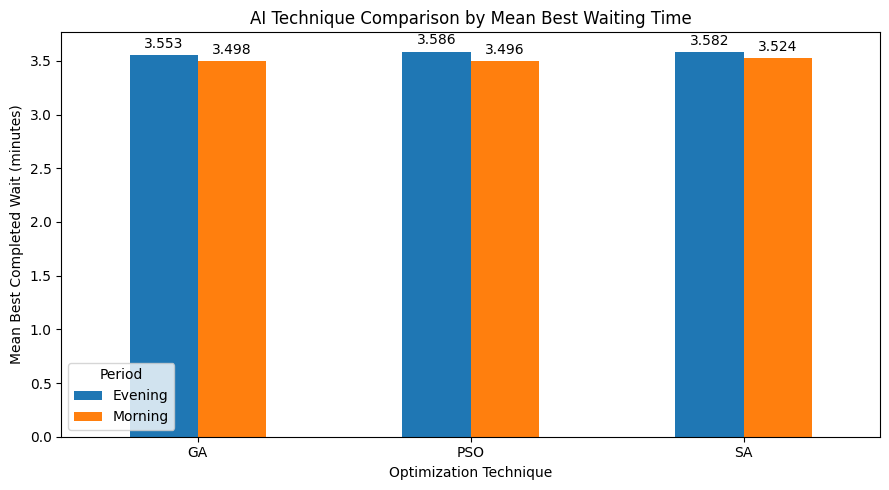

In [42]:
#compare the three ai techniques using their mean best waiting time.
technique_plot = optimizer_summary.pivot(
    index="Technique",
    columns="Period",
    values="Mean_Best_Wait"
)

ax = technique_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("AI Technique Comparison by Mean Best Waiting Time")
plt.xlabel("Optimization Technique")
plt.ylabel("Mean Best Completed Wait (minutes)")
plt.xticks(rotation=0)
plt.legend(title="Period")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "03_ai_technique_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

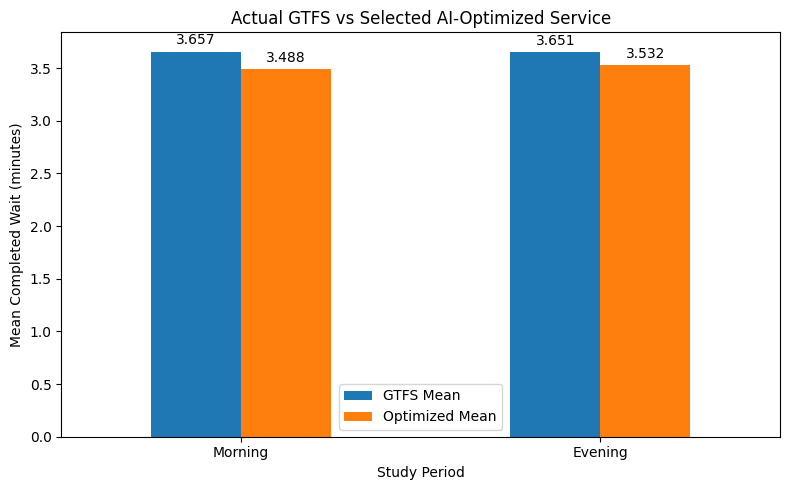

In [43]:
#compare the actual gtfs mean wait with the selected optimized service plan.
wait_chart = wait_comparison[
    ["Period", "GTFS Mean", "Optimized Mean"]
].set_index("Period")

ax = wait_chart.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Actual GTFS vs Selected AI-Optimized Service")
plt.xlabel("Study Period")
plt.ylabel("Mean Completed Wait (minutes)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "04_gtfs_vs_ai_optimized_wait.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
#save the final ai experiment outputs.
optimizer_runs_export = optimizer_runs_df.copy()
optimizer_runs_export["Best Service Plan"] = (
    optimizer_runs_export["Best Service Plan"].astype(str)
)

selected_service_plans_export = selected_service_plans.copy()
selected_service_plans_export["Service Plan"] = (
    selected_service_plans_export["Service Plan"].astype(str)
)

optimizer_runs_export.to_csv(
    tables_dir / "ai_technique_run_results.csv",
    index=False
)

optimizer_summary.to_csv(
    tables_dir / "ai_technique_summary.csv",
    index=False
)

technique_selection.to_csv(
    tables_dir / "ai_technique_selection.csv",
    index=False
)

selected_service_plans_export.to_csv(
    tables_dir / "selected_ai_service_plans.csv",
    index=False
)

optimized_vs_gtfs.to_csv(
    tables_dir / "optimized_vs_gtfs_paired_comparison.csv",
    index=False
)

print("AI evaluation tables saved.")
print("Selected technique:", selected_technique)

AI evaluation tables saved.
Selected technique: GA


### Technical Reference

Detailed data, simulation, optimization, validation, and methodological references are documented in `../docs/TECHNICAL_DOCUMENTATION.md`.
